Mô hình Markov được sử dụng để mô hình hóa lưới chữ nhật với các điểm nút biểu diễn các nguyên tử sắt từ. Các nguyen tử này có thể có giá trị +1 hoặc -1 tương ứng với spin từ up/down

Với các mô hình nhiều chiều hơn, ta cần xét tới quá trình chuyển pha tại nhiệt đọ Curie $T_c$ . Ở dưới nhiệt độ Curie $T_c$, vật liệu từ hoạt động bình thường. Trên nhiệt độ Curie $T_c$, năng lượng nhiệt phá vỡ các liên kết từ, vật liệu hoạt động như vật liệu thuận từ  thông thường

Nếu như không có từ trường từ bên ngoài, với tham số ghép cặp $J>0$, năng lượng từ quá trình từ hóa là : $$E = - J  
    \sum_{(atoms)} \sum_{(neighbor atoms)} (s_{atom}.s_{neighbor})$$

Viết gọn lại như sau : $$E = - J  \sum_{<i,j>}  (s_{i}.s_{j})$$
Mục tiêu của mô hình chính là xác định thâm số $T_c$. Ta sẽ chạy mô hình chuỗi Markov Monte Carlo với nhiều nhiệt độ khác nhau để xác định quá trình từ hóa như hàm của nhiệt độ.

Ví dụ quá trình từ hóa ở dưới và trên nhiệt độ từ hóa
Bên trái là từ hóa 100%, bên phải làn ko từ có từ hóa

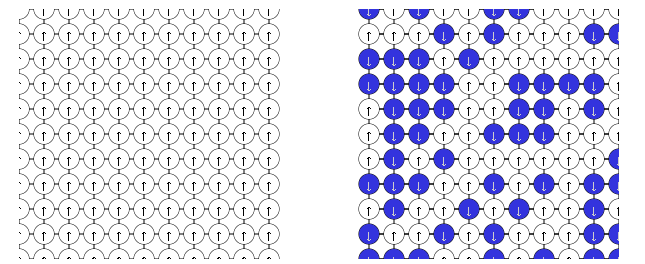

In [8]:
from IPython.display import Image
Image("omg/spin_1.PNG")

Trong mô hình Ising, phân bố của spin trong lưới phu thuộc và nhiệt độ và tuân theo phân bố Boltzmann:   
$\hspace{4cm}$   phân bố tần số ~ $e^{\frac{-E}{kT}}$    
trong đó, k là hằng số Boltzmann, T là nhiệt độ lưới và E là tổng năng lượng từ quá trình từ hóa

Ta có các cách sau

Tính thô thiên điểm cân bằng từ hòa của hệ thống bằng cách chạy vòng lặp qua tất cả các trạng thái có thể của hệ, tính toán năng lượng của 

Phương pháp Metropolis-Hasting  
Ta sẽ đi ngẫu nhiên qua không gian trạng thái, nhưng ta sẽ chạy đến các thạng thái dc thăm thường xuyên một cách thường xuyên hơn. Với mô hình Ising, ta biết các trạng thái spin tuân theo phấn phối Boltzmann :   
phân phối tần số của các trạng thái   ~  $  exp^{frac{-E}{kT}}$

Tạo hàm vẽ

In [10]:
import numpy as np
from array2gif  import write_gif

def to_two_color(lattice):
    blue = np.ones(lattice.shape, dtype = np.int) * 255
    red = np.zeros(lattice.shape, dtype = np.int)
    red[lattice < 0] = 255
    green = red
    return np.array([red, green, blue])

def output_to_gif(dataset, filename, fps = 8):
    print("Frames : {}".format(len(dataset)))
    colors = []
    write_gif(
    [to_two_color(lattice) for lattice in dataset],
    filename, 
    fps = fps)

Hàm get_dH tính $H(x^{'})- H(x) $. Bởi vì chỉ có vị trí $i,j$ thay đổi, ta chỉ cần tính sự thay đổi năng lượng ở vị trí này.

In [14]:
def get_dH(lattice, trial_location):
    """ H = - Sum_<ij>(s_i s_j) """
    i, j = trial_location
    height, width = lattice.shape
    H, Hflip = 0, 0
    for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        ii = (i + di) % height
        jj = (j + dj) % width
        H -= lattice[ii, jj] * lattice[i, j]
        Hflip += lattice[ii, jj] * lattice[i, j]
    return Hflip - H

Hàm standard_approach tạo ra lưới có các giá trị +1/-1 và lặp qua tất cả các trạng thái N * 5 lần, chụp lại hình ở lần thư 5

In [ ]:
def standard_approach(T, width, height, N = 60):
    #randomely initialize the spin o either +1 or -1 